This notebook makes the main plots of the lecture, on going from the time to the frequency domain via the Fast Fourier Transform.

In [1]:
using Plots

In [2]:
using FFTW

# 1. Passing from Time to Frequency Domain

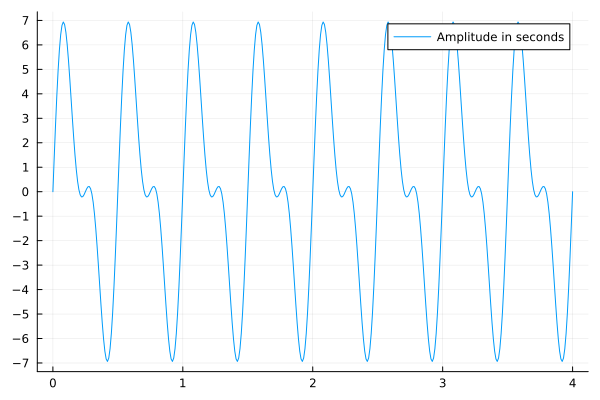

In [3]:
dt = 0.01
t = 0:dt:4
# amplitudes 3 and 5 at frequencies 4 and 2
y = 3*sin.(4*2*pi*t) + 5*sin.(2*2*pi*t)
plot(t,y,yticks=-7:1:7,label="Amplitude in seconds")

In [4]:
#savefig("showfft.png")

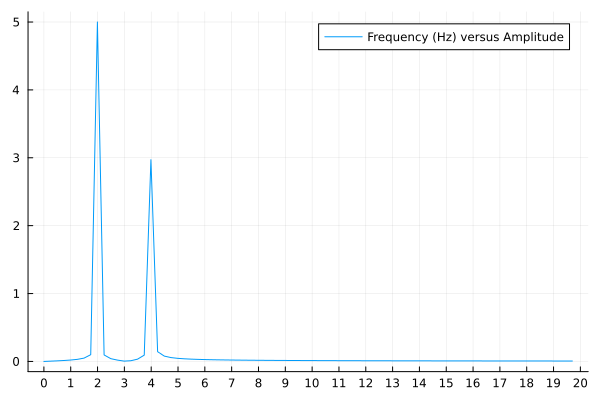

In [5]:
F = fft(y)
n = length(y)/2
amps = abs.(F)/n
freq = [0:79]/(2*n*dt)
plot(freq, amps[1:80], xticks=0:1:20,
     label="Frequency (Hz) versus Amplitude")

In [6]:
#savefig("showfftspectrum.png")

# 2. Timing the Code

How fast is the Fast Fourier Transform?

In [7]:
"""
    Measures the time to do the FFT transform
for an end time given as input parameter.
"""
function doFFT(endtime)
    dt = 0.01
    t = 0:dt:endtime
    y = 3*sin.(4*2*pi*t) + 5*sin.(2*2*pi*t)
    print("length(y) : ", length(y))
    @time F = fft(y)
end

doFFT

We are not interested in seeing the output, so we call `doFFT` with the `;` at the end.

In [8]:
doFFT(4);

length(y) : 401  0.000084 seconds (1.02 k allocations: 61.561 KiB)


In reporting times, we list the computer it runs on.

In [9]:
Sys.cpu_info()

32-element Vector{Base.Sys.CPUinfo}:
 Base.Sys.CPUinfo("13th Gen Intel(R) Core(TM) i9-13900HX", 2419, 0x0000000000ea7443, 0x0000000000000000, 0x00000000018f001a, 0x00000000210520ab, 0x000000000054c5f7)
 Base.Sys.CPUinfo("13th Gen Intel(R) Core(TM) i9-13900HX", 2419, 0x00000000001a1667, 0x0000000000000000, 0x000000000031662d, 0x000000002333169f, 0x000000000007e117)
 Base.Sys.CPUinfo("13th Gen Intel(R) Core(TM) i9-13900HX", 2419, 0x00000000011b8944, 0x0000000000000000, 0x00000000015cdb4f, 0x0000000021062f6c, 0x000000000030dbd0)
 Base.Sys.CPUinfo("13th Gen Intel(R) Core(TM) i9-13900HX", 2419, 0x00000000001ef25d, 0x0000000000000000, 0x00000000003532f5, 0x00000000232a6c3d, 0x00000000000b4b0d)
 Base.Sys.CPUinfo("13th Gen Intel(R) Core(TM) i9-13900HX", 2419, 0x0000000000f8d0d6, 0x0000000000000000, 0x000000000121b279, 0x00000000216410b0, 0x00000000002a5eae)
 Base.Sys.CPUinfo("13th Gen Intel(R) Core(TM) i9-13900HX", 2419, 0x00000000001cb5bb, 0x0000000000000000, 0x00000000002b9cac, 0x00000000233